## EDA

In [301]:
import pandas as pd
import numpy as np
import seaborn as sns

In [302]:
df = pd.read_csv("data/ta_restaurants.csv")
df.head()

,rating,reviews_count,cuisine_type,price,is_sponsored
0,"5,0",3,"Средиземноморская, Греческая",$$ - $$$,True
1,"4,1",97,"Бары и клубы, Стейк-хаус",$$ - $$$,True
2,"4,8",3316,"Французская, Стейк-хаус",$$$$,False
3,"4,3",518,"Китайская, Японская",$,False
4,"4,7",3995,"Итальянская, Пицца",$$ - $$$,False


In [303]:
df.shape

(10499, 5)

In [304]:
df['rating'] = df['rating'].str.replace(',', '.').astype('float')

In [305]:
df.isna().sum()

rating           1818
reviews_count       0
cuisine_type      294
price            4234
is_sponsored        0
dtype: int64

In [306]:
len(df[df['reviews_count'] == 0])

1812

In [307]:
df[(df['reviews_count'] != 0) & (df['rating'].isna())]

,rating,reviews_count,cuisine_type,price,is_sponsored
2740,NaN,1,"Итальянская, Современная",NaN,False
7291,NaN,1,Американская,NaN,False
7445,NaN,1,Американская,NaN,False
7729,NaN,1,"Азиатская, Тайская",NaN,False
7763,NaN,1,Пицца,NaN,False
7810,NaN,1,Японская,NaN,False


В основном, rating отсутствует тогда, когда попросту нет отзывов (1812 случаев из 1818). У остальных 6 всего по 1 отзыву.

In [308]:
df = df.dropna(subset=['rating', 'price', 'cuisine_type'])

In [309]:
price_levels = {'$': 1, '$$': 2, '$$$': 3, '$$$$': 4, '$$$$$': 5}

df['min_price'] = df['price'].str.replace(' ', '').str.split('-').str[0].map(price_levels)
df['max_price'] = df['price'].str.replace(' ', '').str.split('-').str[-1].map(price_levels)

In [310]:
df

,rating,reviews_count,cuisine_type,price,is_sponsored,min_price,max_price
0,5.0,3,"Средиземноморская, Греческая",$$ - $$$,True,2,3
1,4.1,97,"Бары и клубы, Стейк-хаус",$$ - $$$,True,2,3
2,4.8,3316,"Французская, Стейк-хаус",$$$$,False,4,4
3,4.3,518,"Китайская, Японская",$,False,1,1
4,4.7,3995,"Итальянская, Пицца",$$ - $$$,False,2,3
...,...,...,...,...,...,...,...
10463,4.6,56,"Итальянская, Пицца",$$ - $$$,True,2,3
10464,4.5,130,"Бары и клубы, Ирландская",$,True,1,1
10465,4.6,56,"Итальянская, Пицца",$$ - $$$,True,2,3
10482,4.5,27,"Японская, Азиатская",$$ - $$$,True,2,3


In [311]:
df = df[~df['cuisine_type'].fillna('').str.contains(
    r'Откроется|Закроется|Открыто|Сейчас|Сегодня|Меню', regex=True)]
# Чистка от мусорных значений в cuisine_type

In [312]:
df.duplicated().sum()

np.int64(1400)

In [313]:
df = df.drop_duplicates()

In [314]:
df['cuisine_type'] = df['cuisine_type'].str.split(', ')

In [315]:
df

,rating,reviews_count,cuisine_type,price,is_sponsored,min_price,max_price
0,5.0,3,"[Средиземноморская, Греческая]",$$ - $$$,True,2,3
1,4.1,97,"[Бары и клубы, Стейк-хаус]",$$ - $$$,True,2,3
2,4.8,3316,"[Французская, Стейк-хаус]",$$$$,False,4,4
3,4.3,518,"[Китайская, Японская]",$,False,1,1
4,4.7,3995,"[Итальянская, Пицца]",$$ - $$$,False,2,3
...,...,...,...,...,...,...,...
8451,3.8,6,[Азиатская],$$ - $$$,False,2,3
8587,3.0,4,"[Американская, Кафе]",$,False,1,1
8590,3.0,3,[Американская],$,False,1,1
8618,1.0,2,[Гастроном],$$ - $$$,False,2,3


In [316]:
exploded_df = df.explode('cuisine_type')

In [317]:
exploded_df.info()

<class 'pandas.DataFrame'>
Index: 7781 entries, 0 to 8642
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   rating         7781 non-null   float64
 1   reviews_count  7781 non-null   int64  
 2   cuisine_type   7781 non-null   str    
 3   price          7781 non-null   str    
 4   is_sponsored   7781 non-null   bool   
 5   min_price      7781 non-null   int64  
 6   max_price      7781 non-null   int64  
dtypes: bool(1), float64(1), int64(3), str(2)
memory usage: 433.1 KB


In [318]:
avg_rating_by_cuisine = exploded_df.groupby('cuisine_type')['rating'].agg(['mean', 'count', 'std'])

In [319]:
rare_cuisines = avg_rating_by_cuisine[avg_rating_by_cuisine['count'] < 10].index
rare_cuisines

Index(['Австралийская', 'Австрийская', 'Аргентинская', 'Армянская',
       'Афганская', 'Бангладешская', 'Бары с рестораном', 'Баскская',
       'Бельгийская', 'Британская', 'Венесуэльская', 'Восточноевропейская',
       'Гавайская', 'Гастропаб', 'Гриль', 'Грузинская', 'Десерты', 'Кайсэки',
       'Канадская', 'Кантонская', 'Кубинская', 'Малазийская', 'Нонья',
       'Паб с пивоварней', 'Пакистанская', 'Персидская', 'Польская',
       'Португальская', 'Римская', 'Русская', 'Северно-итальянская',
       'Сицилийская', 'Сычуаньская', 'Тайваньская', 'Тибетская', 'Тосканская',
       'Украинская', 'Уличная еда', 'Филиппинская', 'Хорватская',
       'Центральноазиатская', 'Центральноамериканская', 'Чешская',
       'Шанхайская', 'Шведская', 'Швейцарская', 'Шриланкийская', 'Эфиопская',
       'Южноамериканская', 'Юнаньская', 'Ямайская', 'Японская кухня-фьюжн'],
      dtype='str', name='cuisine_type')

In [320]:
exploded_df = exploded_df[~exploded_df['cuisine_type'].isin(rare_cuisines)]
exploded_df['cuisine_type'].value_counts().tail(10)

cuisine_type
Ливанская                  26
Африканская                25
Перуанская                 21
Израильская                16
Юговосточная               14
Супы                       14
Бразильская                14
Каджунская и креольская    14
Немецкая                   11
Марокканская               10
Name: count, dtype: int64

In [321]:
avg_rating_by_cuisine = avg_rating_by_cuisine.drop(index=rare_cuisines)

In [322]:
avg_rating_by_cuisine.sort_values('mean', ascending=False).head(10)

,mean,count,std
cuisine_type,,,
Ливанская,4.357692,26,0.480144
Африканская,4.344000,25,0.432127
Вьетнамская,4.334483,29,0.335171
Корейская,4.322000,50,0.355304
Супы,4.292857,14,0.391180
Тайская,4.274468,94,0.468339
Современная,4.264384,73,0.339677
Международная,4.262295,61,0.340178
Здоровая,4.258824,51,0.577296


In [323]:
avg_rating_by_cuisine.sort_values('count', ascending=False).head(10)

,mean,count,std
cuisine_type,,,
Американская,4.107213,1317,0.475559
Итальянская,4.189089,779,0.441278
Бар,4.099347,613,0.449691
Азиатская,4.182726,521,0.416359
Японская,4.233962,371,0.408729
Пицца,4.162848,323,0.465633
Китайская,3.996642,268,0.524269
Кафе,4.159917,242,0.480669
Мексиканская,4.083830,235,0.451202


<Axes: ylabel='cuisine_type'>

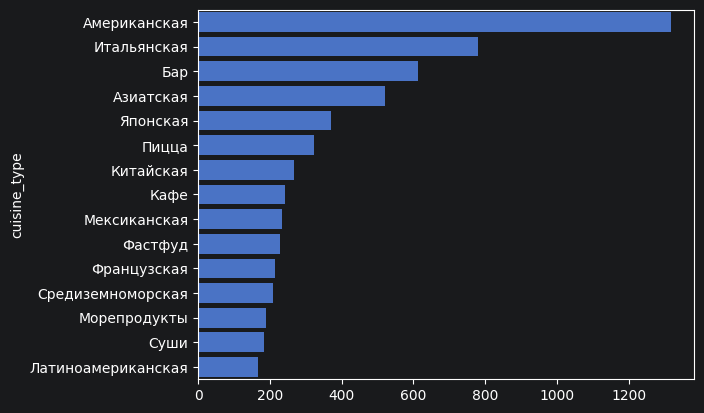

In [324]:
top_cuisines = exploded_df['cuisine_type'].value_counts().head(15)

sns.barplot(x=top_cuisines.values, y=top_cuisines.index)

<Axes: xlabel='rating', ylabel='Count'>

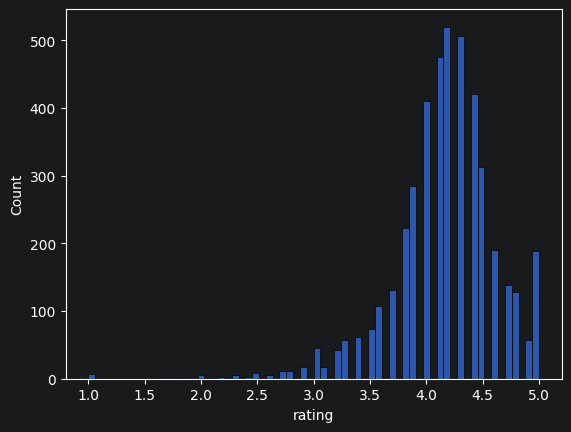

In [325]:
sns.histplot(data=df, x='rating')

In [326]:
df.sort_values('reviews_count', ascending=False).head(10)

,rating,reviews_count,cuisine_type,price,is_sponsored,min_price,max_price
6265,4.1,23628,"[Американская, Закусочная]",$$ - $$$,True,2,3
36,4.1,23628,"[Десерты, Американская]",$$ - $$$,True,2,3
17,4.2,18638,"[Гастроном, Израильская]",$$ - $$$,False,2,3
74,4.2,15153,"[Американская, Морепродукты]",$$ - $$$,False,2,3
77,4.4,13419,"[Итальянская, Пицца]",$$ - $$$,False,2,3
58,4.5,7011,"[Американская, Стейк-хаус]",$$$$,False,4,4
62,4.4,6803,"[Итальянская, Стейк-хаус]",$$ - $$$,False,2,3
61,4.3,6666,"[Французская, Европейская]",$$$$,False,4,4
100,4.2,6299,"[Итальянская, Пицца]",$$ - $$$,False,2,3
23,3.8,5746,"[Американская, Стейк-хаус]",$$$$,False,4,4


<Axes: xlabel='reviews_count', ylabel='Count'>

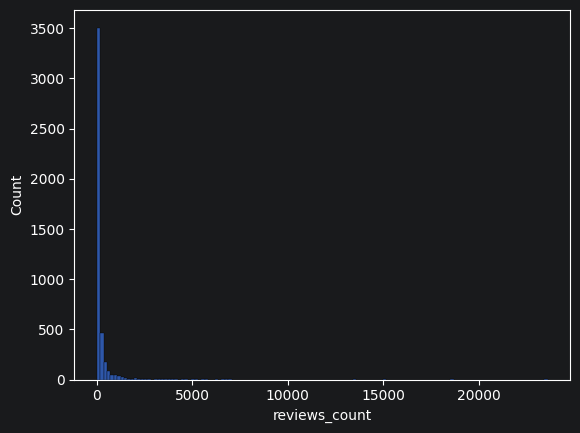

In [327]:
sns.histplot(data=df, x='reviews_count')

In [328]:
pivot_rating = df.groupby(['min_price', 'max_price'])['rating'].mean().reset_index()

In [329]:
corr_df = pivot_rating.corr()
corr_df

,min_price,max_price,rating
min_price,1.000000,0.928571,0.999909
max_price,0.928571,1.000000,0.933484
rating,0.999909,0.933484,1.000000


<Axes: >

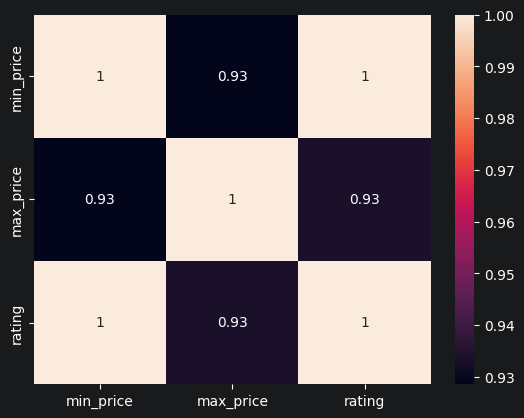

In [330]:
sns.heatmap(corr_df, annot=True)

<Axes: xlabel='min_price', ylabel='rating'>

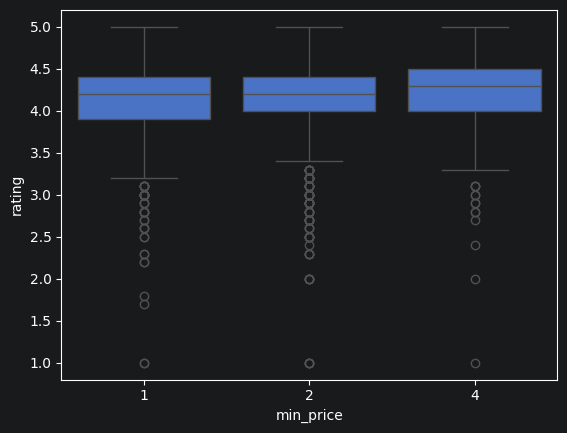

In [331]:
sns.boxplot(data=df, x='min_price', y='rating')

<Axes: xlabel='is_sponsored', ylabel='rating'>

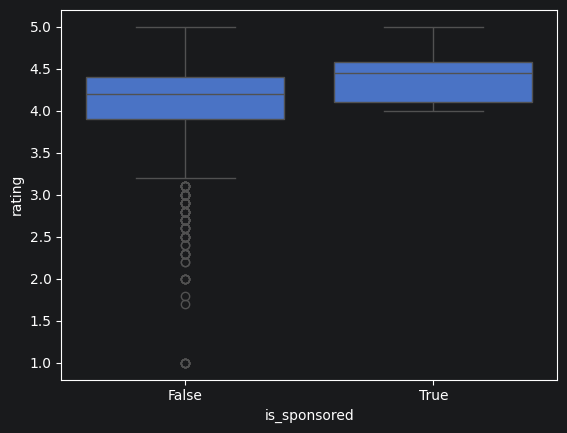

In [335]:
sns.boxplot(data=df, x='is_sponsored', y='rating')

<Axes: xlabel='reviews_count', ylabel='rating'>

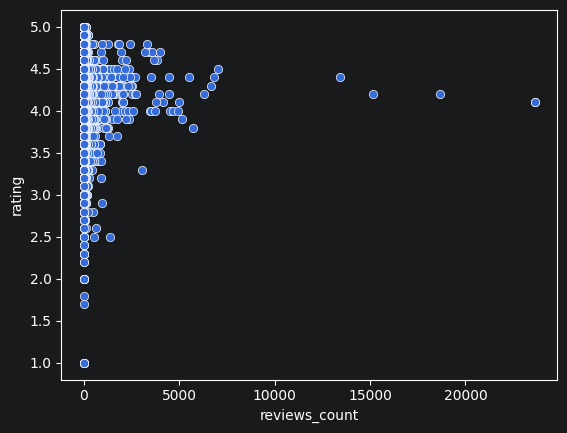

In [337]:
sns.scatterplot(data=df, x='reviews_count', y='rating')